### Build a Basic Chatbot With Langgraph (Graph API)


In [23]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
    # Messages have the type "list". Te 'add_messages' function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

# graph_builder = StateGraph(State)

In [25]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [26]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")


In [27]:
llm = init_chat_model("groq:llama-3.1-8b-instant")

In [28]:
## Node Functionality
def chatbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

In [29]:
graph_builder = StateGraph(State)
#Add Node
graph_builder.add_node("llmchatbot", chatbot)
# Add Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph=graph_builder.compile()

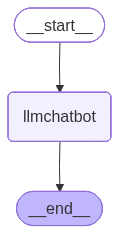

In [30]:
## Visualtize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [32]:
response=graph.invoke({"messages": "Hi"})

In [33]:
for event in graph.stream({"messages":"Hi, How are you?"}):
    for val in event.values():
        print(val["messages"][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How can I assist you today?


### Chatbot with TOOL

In [ ]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tools=[tool]

tool.invoke("What is Langgraph?")

In [ ]:
from httpx import __description__
## Custom Function

def multiply(a:int, b:int) -> int:
    """ Multiply a and b 

    Args:
        a (int): first int
        b (int): second int
    Returns:
        int: output int

    """
    return a*b

In [ ]:
tools=[tool, multiply]

In [ ]:
llm_with_tools = llm.bind_tools(tools)

In [ ]:
## StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest  message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

## Compile the graph
graph=builder.compile()


from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png))


In [ ]:
response=graph.invoke({"messages": "What is the recent AI news?"})
response["messages"][-1].content

for m in response["messages"]:
    m.pretty_print()

In [ ]:
## ReACT Agent Architecture

## StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest  message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## Compile the graph
graph=builder.compile()


from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png))


## Adding Memory in Agentic Graph

In [ ]:
## ReACT Agent Architecture

## StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest  message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## Compile the graph
graph=builder.compile(checkpointer=memory)


from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png))


In [ ]:
config = {"configurable": {"thread": "1"}}

response = graph.invoke({"messages":"Hi, My name is Fatin"}, config=config)

for m in response["messages"]:
    m.pretty_print()

## Streaming

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [ ]:
def superbot(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [ ]:
graph = StateGraph(State)

## node
graph.add_node("Superbot", superbot)

## edges
graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile(checkpointer=memory)

## Display

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
## Invocation
config = {"configurable":{"thread":"1"}}
response = graph_builder.invoke({"messages": "Hi, My name is Newt and I like Football"}, config)


### Streaming methods

Methods: .stream() and astream()

  * These methods are sync and async mehods for streaming back results.

Additional parameters in streaming modes for graph state

  * **values**: This streams the full state of the graph after each node is called.
  * **updates**: This streams updates to the state of the graph after each node is called.


In [ ]:
# Create a thread
config = { {"configurable":{"thread":"3"}} }

for chunk in graph_builder.stream({"messages": "Hi, My name is Newt and I like Football"}, config, stream_mode="updates"):
    print(chunk)

for chunk in graph_builder.stream({"messages": "Hi, My name is Newt and I like Football"}, config, stream_mode="values"):
    print(chunk)

In [ ]:
config = {"configurable":{"thread_id":"4"}}
async for event in graph_builder.astream_events({"messages":["Hi my name is Newt and I love Football"]}, config, version="v2"):
    print(event)

## Human in the Loop

In [ ]:
import os
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

In [ ]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """ Request assistance from human. """
    human_response = interrupt("query":query)
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state:State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.staticmethod
    return {"messages": [message]}

graph_builder.add_node("chatbot",chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [ ]:
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [ ]:
user_input = "I need some expert guidance and assistance for building an AI agent."
config = { "configurable" : {"thread_id": "1"}}

events = graph.stream(
    {"messages":user_input},
    config,
    stream_mode="values"
)

for event in events:
    if "message" in event:
        event["message"][-1].pretty_print()

In [ ]:
human_response = (
    "We, the experts, are here to help! We'd recommend you check out Langgraph to build your agent"
    " It's much more reliable and extensible than simpple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()